1. Data Preprocessing

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import confusion_matrix

import tensorflow as tf
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers import Flatten, Dense, Dropout
from tensorflow.keras.utils import to_categorical

In [6]:
# Load dataset
(X_train, y_train), (X_test, y_test) = mnist.load_data()

# Normalize pixel values
X_train = X_train / 255.0
X_test = X_test / 255.0

# Reshape dataset for CNN
X_train = X_train.reshape(-1, 28, 28, 1)
X_test = X_test.reshape(-1, 28, 28, 1)

# Convert labels into categorical format
y_train_cat = to_categorical(y_train, 10)
y_test_cat = to_categorical(y_test, 10)

CNN Model Implementation

In [7]:
# Build CNN model
model = Sequential()

# First convolution layer
model.add(Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)))

# Pooling layer
model.add(MaxPooling2D((2,2)))

# Second convolution layer
model.add(Conv2D(64, (3,3), activation='relu'))

# Flatten layer
model.add(Flatten())

# Fully connected layer
model.add(Dense(128, activation='relu'))

# Dropout layer
model.add(Dropout(0.5))

# Output layer
model.add(Dense(10, activation='softmax'))

5. Model Training

In [8]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
history = model.fit(
    X_train,
    y_train_cat,
    epochs=10,
    validation_split=0.2,
    batch_size=64
)

Epoch 1/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 52s 67ms/step - accuracy: 0.9320 - loss: 0.2270 - val_accuracy: 0.9831 - val_loss: 0.0595
Epoch 2/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 50s 67ms/step - accuracy: 0.9753 - loss: 0.0802 - val_accuracy: 0.9856 - val_loss: 0.0479
Epoch 3/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 81s 65ms/step - accuracy: 0.9828 - loss: 0.0574 - val_accuracy: 0.9887 - val_loss: 0.0391
Epoch 4/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 90s 76ms/step - accuracy: 0.9863 - loss: 0.0451 - val_accuracy: 0.9889 - val_loss: 0.0376
Epoch 5/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 59s 78ms/step - accuracy: 0.9885 - loss: 0.0369 - val_accuracy: 0.9881 - val_loss: 0.0438
Epoch 6/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 47s 63ms/step - accuracy: 0.9897 - loss: 0.0322 - val_accuracy: 0.9908 - val_loss: 0.0339
Epoch 7/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 85s 67ms/step - accuracy: 0.9912 - loss: 0.0270 - val_accuracy: 0.9898 - val_loss: 0.0376
Epoch 8/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 81s 66ms/step - accuracy: 0.9923 - loss: 0.0225 - 

6. Model Evaluation

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step


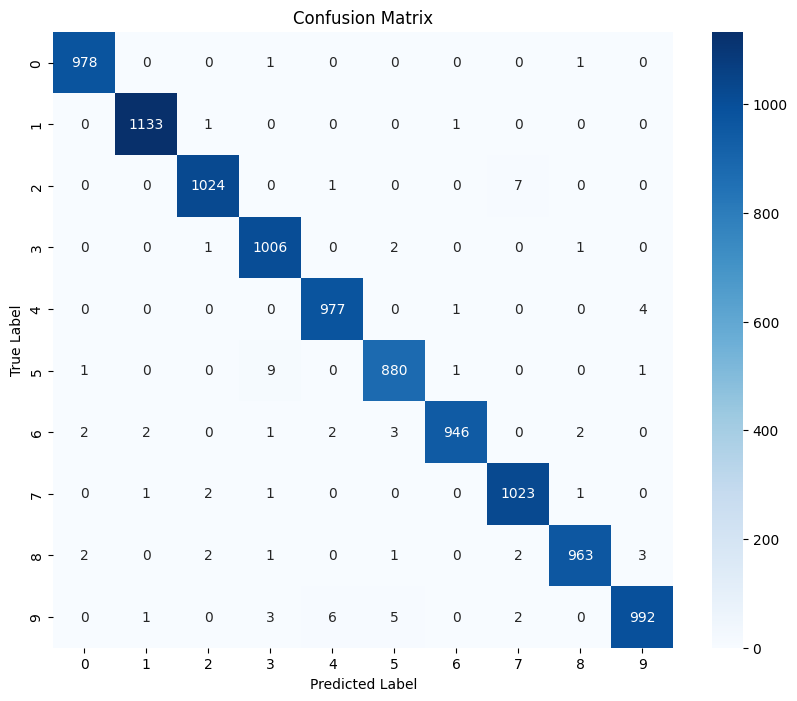

In [9]:
# Predict classes
predictions = model.predict(X_test)
predicted_classes = np.argmax(predictions, axis=1)

# Confusion matrix
cm = confusion_matrix(y_test, predicted_classes)

# Plot confusion matrix
plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

7. Visualization

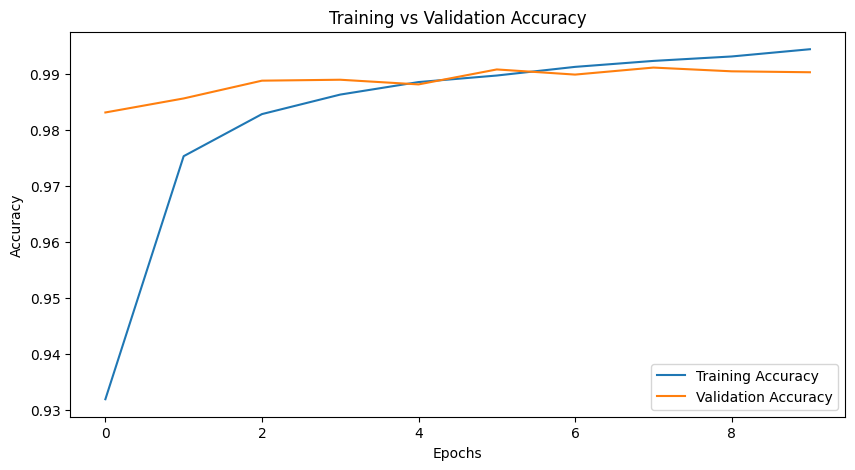

In [10]:
# Plot training & validation accuracy
plt.figure(figsize=(10,5))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')
plt.legend()
plt.show()

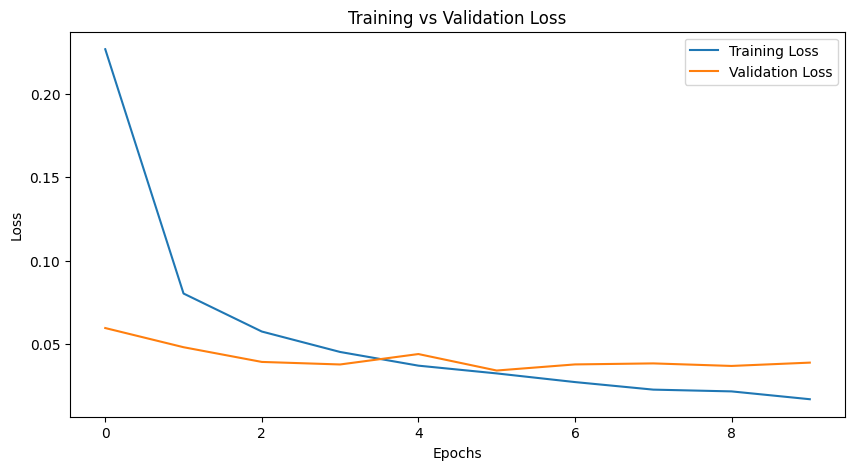

In [11]:
# Plot training & validation loss
plt.figure(figsize=(10,5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.show()

# **Analysis Questions**
## Question 1: What is the role of convolution layers?




Convolution layers extract important features from images such as edges, textures, patterns, and shapes. These layers help the CNN understand spatial information inside images.

Question 2: Why is pooling used?

Pooling reduces the size of feature maps. It decreases computational complexity, reduces overfitting, and helps the model focus on important features.

Question 3: What happens if we increase the number of filters?

Increasing the number of filters allows the model to learn more complex image features. However, too many filters increase computational cost and may lead to overfitting.

Question 4: What is overfitting in CNN? Did it occur in your model?

Overfitting occurs when a model performs very well on training data but poorly on unseen testing data.

In this model, overfitting was controlled using:

Dropout Layer
Validation Split
Proper Number of Epochs

The model showed very close training and validation accuracy, so significant overfitting did not occur.